# Data Understanding & Initial Dataset Profiling

## IEEE-CIS Fraud Detection Dataset

This notebook is aligned with the current `graph-fraud-ai` project architecture.

It uses:
- `src/data/loader.py` as the single dataset loading pipeline
- `configs/data_config.yaml` for dataset configuration
- `data/raw/` as the raw dataset location

Phase 2 objective:
- Confirm dataset loading works
- Understand schema
- Inspect fraud imbalance
- Profile missing values
- Prepare for Phase 3 EDA


In [1]:
# Imports & Project Path Setup

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
# Locate project root automatically
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root:")
print(PROJECT_ROOT)

# Configuration file location from project root
CONFIG_PATH = os.path.join(
    PROJECT_ROOT,
    "configs",
    "data_config.yaml"
)

print("\nConfig path:")
print(CONFIG_PATH)
print("Config exists:", os.path.exists(CONFIG_PATH))


Project Root:
/Users/airm2/Desktop/My ML Material/graph-fraud-ai

Config path:
/Users/airm2/Desktop/My ML Material/graph-fraud-ai/configs/data_config.yaml
Config exists: True


In [2]:
# Load project configuration and dataset loader

from src.data.loader import load_ieee_dataset, load_config

config = load_config(CONFIG_PATH)

print("Configuration loaded successfully")
print(config.keys())


Configuration loaded successfully
dict_keys(['dataset', 'paths', 'files', 'target', 'merge', 'processing'])


In [3]:
# Verify paths before loading dataset

print("Working directory:")
print(os.getcwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nConfig exists:")
print(os.path.exists(CONFIG_PATH))

print("\nRaw data folder exists:")
print(os.path.exists(os.path.join(PROJECT_ROOT, "data", "raw")))


Working directory:
/Users/airm2/Desktop/My ML Material/graph-fraud-ai/notebooks

Project root:
/Users/airm2/Desktop/My ML Material/graph-fraud-ai

Config exists:
True

Raw data folder exists:
True


In [4]:
# Load dataset through project pipeline

df = load_ieee_dataset(CONFIG_PATH)

print("\nDataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()


Loading transaction dataset...
Loading identity dataset...

Transaction shape:
(590540, 394)

Identity shape:
(144233, 41)

Merging datasets...

Merged dataset shape:
(590540, 434)

Dataset loaded successfully
Dataset shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
# Dataset information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [6]:
# Fraud target distribution

fraud_distribution = pd.DataFrame({
    "count": df["isFraud"].value_counts(),
    "percentage": (
        df["isFraud"]
        .value_counts(normalize=True)
        .mul(100)
    )
})

fraud_distribution


,count,percentage
isFraud,,
0,569877,96.500999
1,20663,3.499001


In [7]:
# Missing value analysis

missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    .div(len(df))
    .mul(100)
)

missing_summary.head(20)


,missing_count,missing_percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [8]:
# Basic numerical statistics

df.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.358321,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162522,0.251,43.321,68.769,125.0,31937.391
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card1,590540.0,NaN,NaN,NaN,9898.734658,4901.170153,1000.0,6019.0,9678.0,14184.0,18396.0
card2,581607.0,NaN,NaN,NaN,362.555488,157.793246,100.0,214.0,361.0,512.0,600.0
card3,588975.0,NaN,NaN,NaN,153.194925,11.336444,100.0,150.0,150.0,150.0,231.0
card4,588963,4,visa,384767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card5,586281.0,NaN,NaN,NaN,199.278897,41.244453,100.0,166.0,226.0,226.0,237.0


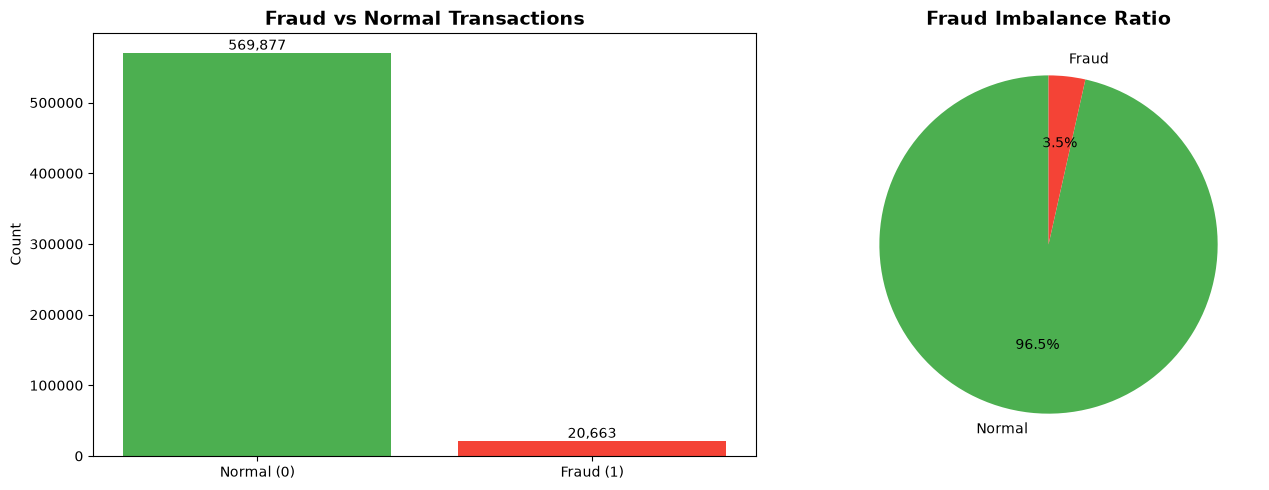


Fraud Rate: 3.50%
Imbalance Ratio: 1:28 (Normal:Fraud)


In [9]:
# ============================================================================
# 9. Target Distribution Visualization
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], fraud_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Fraud vs Normal Transactions', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
fraud_pct = df['isFraud'].mean() * 100
axes[1].pie(
    [100 - fraud_pct, fraud_pct],
    labels=['Normal', 'Fraud'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Fraud Imbalance Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFraud Rate: {fraud_pct:.2f}%")
print(f"Imbalance Ratio: 1:{(100 - fraud_pct) / fraud_pct:.0f} (Normal:Fraud)")


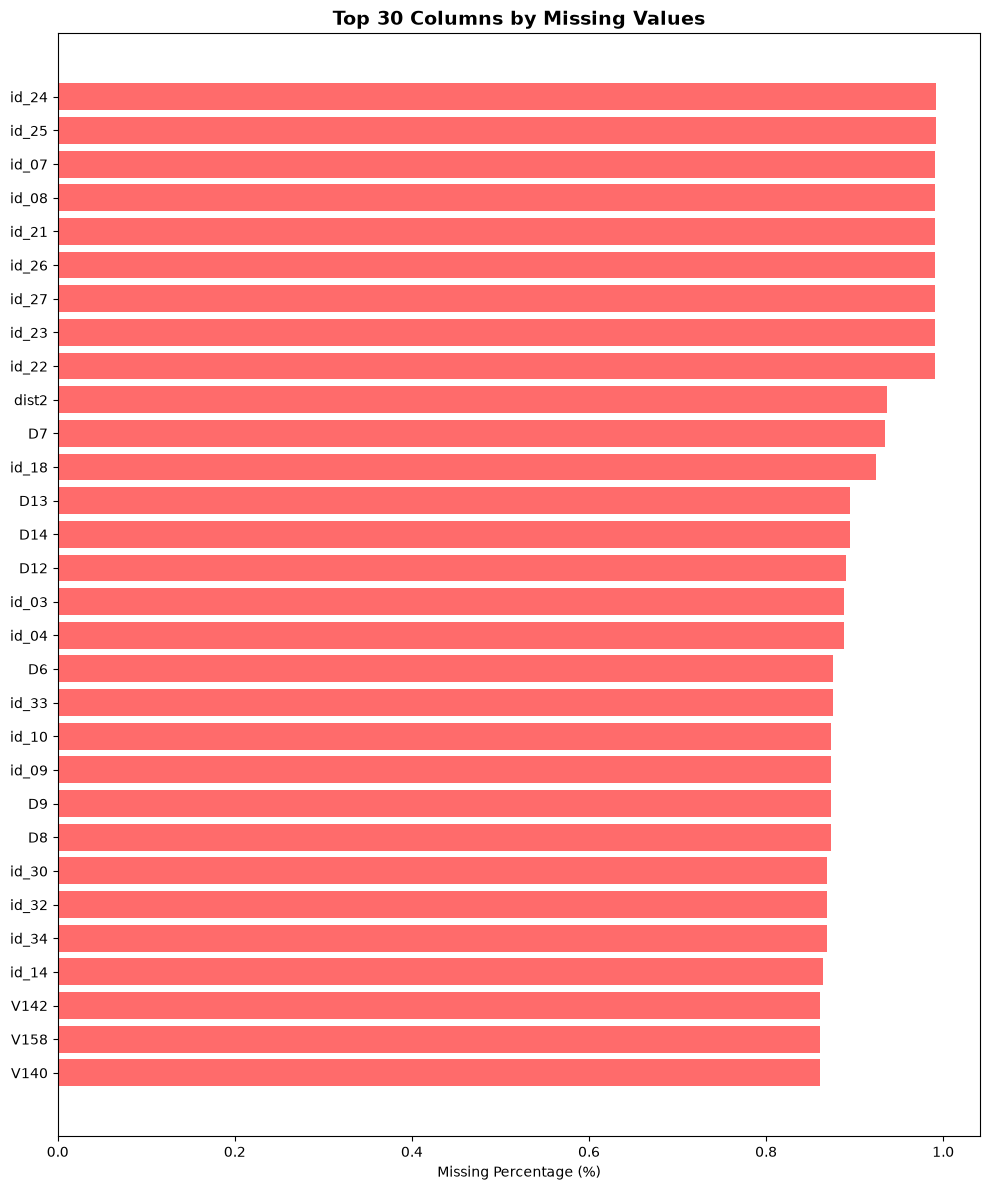

In [10]:
# ============================================================================
# 10. Missing Value Heatmap (Top 30 columns)
# ============================================================================
missing_top30 = df.isnull().mean().sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 12))
plt.barh(missing_top30.index[::-1], missing_top30.values[::-1], color='#FF6B6B')
plt.xlabel('Missing Percentage (%)')
plt.title('Top 30 Columns by Missing Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# ============================================================================
# 11. Data Types Breakdown
# ============================================================================
print("=" * 70)
print("DATA TYPES BREAKDOWN")
print("=" * 70)

dtypes = df.dtypes
print(f"\nNumerical columns: {len(dtypes[dtypes != 'object'])}")
print(f"Categorical columns: {len(dtypes[dtypes == 'object'])}")

print("\n--- Key Numerical Features ---")
num_cols = [c for c in df.columns if df[c].dtype != 'object' and 'TransactionAmt' in c or c in ['dist1', 'TransactionDT']]
for c in ['TransactionAmt', 'TransactionDT', 'dist1']:
    if c in df.columns:
        print(f"  {c}: min={df[c].min():.2f}, max={df[c].max():.2f}, mean={df[c].mean():.2f}")

print("\n--- Key Categorical Features ---")
cat_cols = [c for c in df.columns if df[c].dtype == 'object'][:10]
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} unique values")


DATA TYPES BREAKDOWN

Numerical columns: 403
Categorical columns: 31

--- Key Numerical Features ---
  TransactionAmt: min=0.25, max=31937.39, mean=135.03
  TransactionDT: min=86400.00, max=15811131.00, mean=7372311.31
  dist1: min=0.00, max=10286.00, mean=118.50

--- Key Categorical Features ---
  ProductCD: 5 unique values
  card4: 4 unique values
  card6: 4 unique values
  P_emaildomain: 59 unique values
  R_emaildomain: 60 unique values
  M1: 2 unique values
  M2: 2 unique values
  M3: 2 unique values
  M4: 3 unique values
  M5: 2 unique values



## 12. Initial Findings Summary

### Key Observations:

1. **High Imbalance:** The dataset contains ~3.5% fraud transactions, confirming a highly imbalanced classification problem.
2. **Missing Values:** Identity features have significant missing data (>50% for many columns), requiring careful preprocessing.
3. **Feature Richness:** With 394 columns across transaction and identity data, there are numerous opportunities for feature engineering.
4. **Relational Patterns:** Shared card numbers, devices, and email addresses suggest that transactions are interconnected.

### Implications for Graph Construction:

The presence of shared entities (cards, devices, emails, addresses) across transactions strongly supports representing this data as a **heterogeneous graph**. Relationships such as:

- `transaction → uses → card`
- `transaction → from_device → device_fingerprint`
- `transaction → from_ip → ip_address`

will enable GNN models to learn fraud patterns from the graph topology rather than just individual features.

### Next Steps:

Proceed to Notebook 02 (Exploratory Analysis) to understand fraud behaviour patterns, then Notebook 03 for preprocessing and feature engineering.
